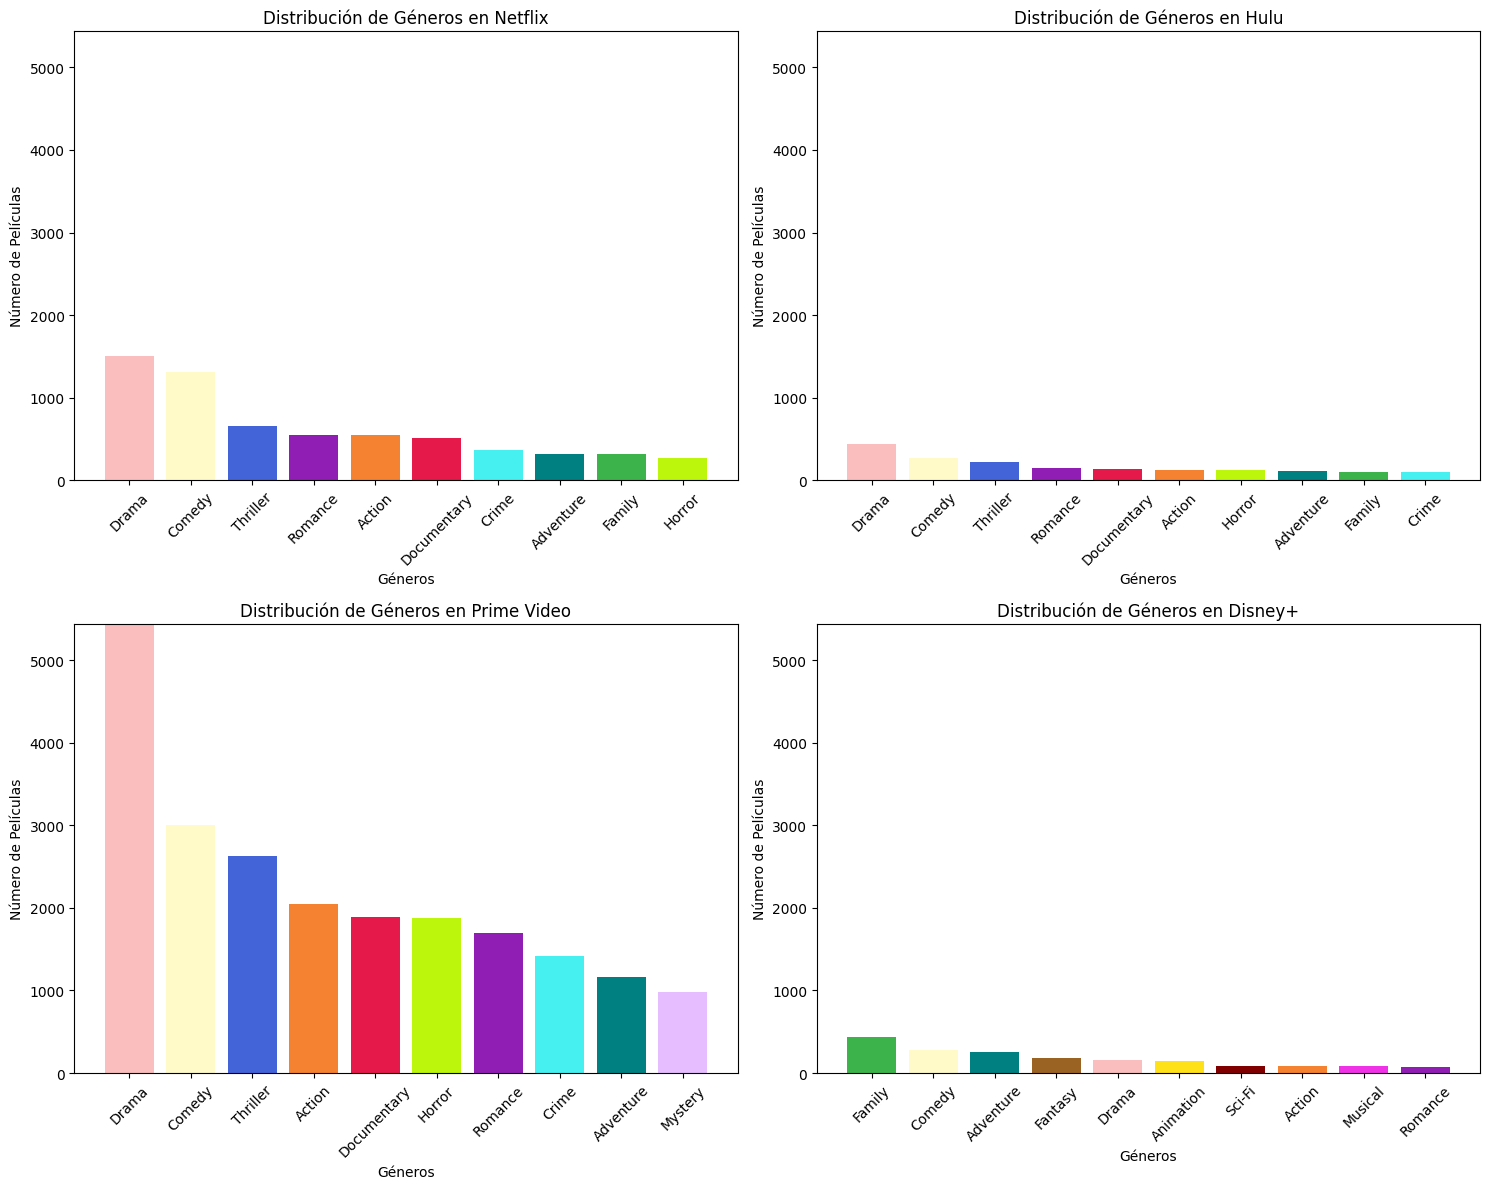

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar el dataset
df = pd.read_csv('/Users/pablojorge/Desktop/Repositorios/ProgramacionDOS/Archivos/MoviesOnStreamingPlatforms_updated.csv')


# Asegurarse de que la columna 'Genres' no tenga valores nulos
df['Genres'].fillna('', inplace=True)

# Separar los géneros (en caso de que estén en formato separado por comas)
df['Genres'] = df['Genres'].str.split(',')

# Expandir la lista de géneros en filas separadas
df_exploded = df.explode('Genres')

# Filtrar películas disponibles en cada plataforma y contar géneros
def count_genres(platform_column):
    df_platform = df_exploded[df_exploded[platform_column] == 1]
    return df_platform['Genres'].value_counts().head(10)

generos_netflix = count_genres('Netflix')
generos_hulu = count_genres('Hulu')
generos_prime = count_genres('Prime Video')
generos_disney = count_genres('Disney+')

# Obtener todos los géneros únicos para asegurar que los colores sean consistentes
all_genres = list(set(generos_netflix.index).union(set(generos_hulu.index), set(generos_prime.index), set(generos_disney.index)))

# Definir un conjunto de colores
colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0', '#f032e6', '#bcf60c', '#fabebe', '#008080', '#e6beff', '#9a6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', '#000075', '#808080']
color_map = dict(zip(all_genres, colors))

# Crear una figura con 2x2 subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# Función para crear el gráfico de barras
def plot_genre_distribution(ax, data, title, color_map):
    colors = [color_map[genre] for genre in data.index]
    ax.bar(data.index, data.values, color=colors)
    ax.set_title(title)
    ax.set_xlabel('Géneros')
    ax.set_ylabel('Número de Películas')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylim(0, max(max(generos_netflix), max(generos_hulu), max(generos_prime), max(generos_disney)))

# Gráfico de barras para géneros más comunes en cada plataforma
plot_genre_distribution(axs[0, 0], generos_netflix, 'Distribución de Géneros en Netflix', color_map)
plot_genre_distribution(axs[0, 1], generos_hulu, 'Distribución de Géneros en Hulu', color_map)
plot_genre_distribution(axs[1, 0], generos_prime, 'Distribución de Géneros en Prime Video', color_map)
plot_genre_distribution(axs[1, 1], generos_disney, 'Distribución de Géneros en Disney+', color_map)

# Ajustar el layout
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [4]:
df

,Unnamed: 0,ID,Title,Year,Age,IMDb,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Directors,Genres,Country,Language,Runtime
0,0,1,Inception,2010,13+,8.8,87%,1,0,0,0,0,Christopher Nolan,"[Action, Adventure, Sci-Fi, Thriller]","United States,United Kingdom","English,Japanese,French",148.0
1,1,2,The Matrix,1999,18+,8.7,87%,1,0,0,0,0,"Lana Wachowski,Lilly Wachowski","[Action, Sci-Fi]",United States,English,136.0
2,2,3,Avengers: Infinity War,2018,13+,8.5,84%,1,0,0,0,0,"Anthony Russo,Joe Russo","[Action, Adventure, Sci-Fi]",United States,English,149.0
3,3,4,Back to the Future,1985,7+,8.5,96%,1,0,0,0,0,Robert Zemeckis,"[Adventure, Comedy, Sci-Fi]",United States,English,116.0
4,4,5,"The Good, the Bad and the Ugly",1966,18+,8.8,97%,1,0,1,0,0,Sergio Leone,[Western],"Italy,Spain,West Germany",Italian,161.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16739,16739,16740,The Ghosts of Buxley Hall,1980,NaN,6.2,NaN,0,0,0,1,0,Bruce Bilson,"[Comedy, Family, Fantasy, Horror]",United States,English,120.0
16740,16740,16741,The Poof Point,2001,7+,4.7,NaN,0,0,0,1,0,Neal Israel,"[Comedy, Family, Sci-Fi]",United States,English,90.0
16741,16741,16742,Sharks of Lost Island,2013,NaN,5.7,NaN,0,0,0,1,0,Neil Gelinas,[Documentary],United States,English,NaN
16742,16742,16743,Man Among Cheetahs,2017,NaN,6.6,NaN,0,0,0,1,0,Richard Slater-Jones,[Documentary],United States,English,NaN


In [2]:
import pandas as pd 

df = pd.read_csv('/Users/pablojorge/Desktop/Repositorios/ProgramacionDOS/Archivos/MoviesOnStreamingPlatforms_updated.csv')

In [3]:
print(df[['IMDb', 'Rotten Tomatoes', 'Directors','Genres']].isnull().sum())

# Reemplazar valores nulos según las indicaciones
df['IMDb'].fillna('Sin calificar', inplace=True)
df['Rotten Tomatoes'].fillna('Sin calificación', inplace=True)
df['Directors'].fillna(' ', inplace=True)
df['Genres'].fillna('Sin genero', inplace=True)

# Verificar que los valores nulos han sido reemplazados
print(df[['IMDb', 'Rotten Tomatoes', 'Directors','Genres']].isnull().sum())

IMDb                 571
Rotten Tomatoes    11586
Directors            726
Genres               275
dtype: int64
IMDb               0
Rotten Tomatoes    0
Directors          0
Genres             0
dtype: int64


In [4]:
s = df["Genres"].apply(lambda x: str(x).split(",")).dropna()
# print(s)
generos = {x for y in s for x in y }
generos


{'Action',
 'Adventure',
 'Animation',
 'Biography',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Family',
 'Fantasy',
 'Film-Noir',
 'Game-Show',
 'History',
 'Horror',
 'Music',
 'Musical',
 'Mystery',
 'News',
 'Reality-TV',
 'Romance',
 'Sci-Fi',
 'Short',
 'Sin genero',
 'Sport',
 'Talk-Show',
 'Thriller',
 'War',
 'Western'}

In [5]:
s

0        [Action, Adventure, Sci-Fi, Thriller]
1                             [Action, Sci-Fi]
2                  [Action, Adventure, Sci-Fi]
3                  [Adventure, Comedy, Sci-Fi]
4                                    [Western]
                         ...                  
16739        [Comedy, Family, Fantasy, Horror]
16740                 [Comedy, Family, Sci-Fi]
16741                            [Documentary]
16742                            [Documentary]
16743             [Documentary, Short, Family]
Name: Genres, Length: 16744, dtype: object

In [6]:
t = df[['IMDb']]
lista = []
for x in generos:
    u = pd.concat([t,s, pd.DataFrame([ x in y for y in s])], axis=1)
    w = u[(u[0] == True) & (u['IMDb'] != 'Sin calificar')]
    lista.append(w['IMDb'].mean())
    # print(w)
# z =w.dropna(subset = ['IMDb'])
print(pd.DataFrame(lista,generos))

                    0
Reality-TV   5.600000
Biography    6.808674
Fantasy      5.685089
Short        6.441228
Crime        5.870569
Drama        6.075494
Horror       4.724303
Music        6.600000
Sport        6.417857
Sin genero   6.105941
Animation    6.252129
Family       6.022900
Comedy       5.905568
Romance      6.044882
Musical      6.236683
Western      5.901420
Film-Noir    6.332911
News         7.109901
Sci-Fi       4.956168
Game-Show    6.133333
Mystery      5.646086
Talk-Show    5.846667
War          6.250380
Documentary  6.942612
Action       5.449831
Adventure    5.615385
History      6.731746
Thriller     5.352066


In [94]:
z.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 526 entries, 6 to 16571
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   IMDb    526 non-null    float64
 1   Genres  526 non-null    object 
 2   0       526 non-null    bool   
dtypes: bool(1), float64(1), object(1)
memory usage: 12.8+ KB


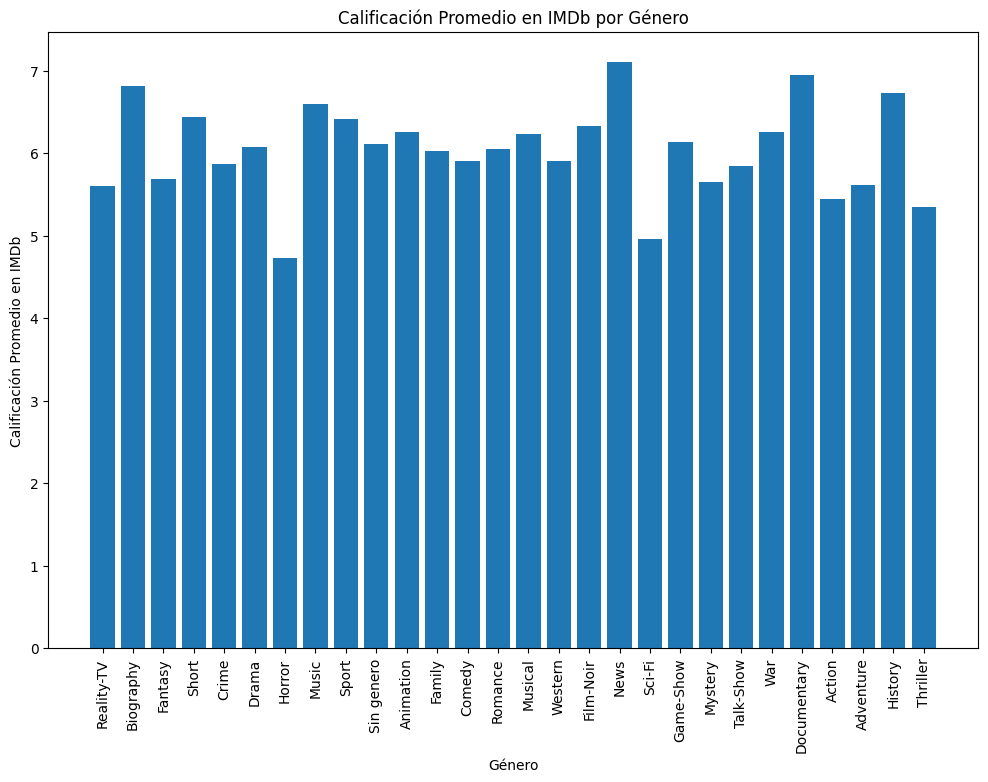

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))


plt.bar(list(generos), lista)

plt.title('Calificación Promedio en IMDb por Género')
plt.xlabel('Género')
plt.ylabel('Calificación Promedio en IMDb')
plt.xticks(rotation=90)

plt.show()



In [35]:
mejor_calificadas = pd.concat([pd.Series(list(generos)),pd.Series(lista)], axis=1).rename(columns={0:"Genero",1:"Cal_Promedio"})
# print(mejor_calificadas)
print('Los géneros con mejores calificaciones son:\n\n', mejor_calificadas.sort_values('Cal_Promedio', ascending = False).head(5))



Los géneros con mejores calificaciones son:

          Genero  Cal_Promedio
17         News      7.109901
23  Documentary      6.942612
1     Biography      6.808674
26      History      6.731746
7         Music      6.600000


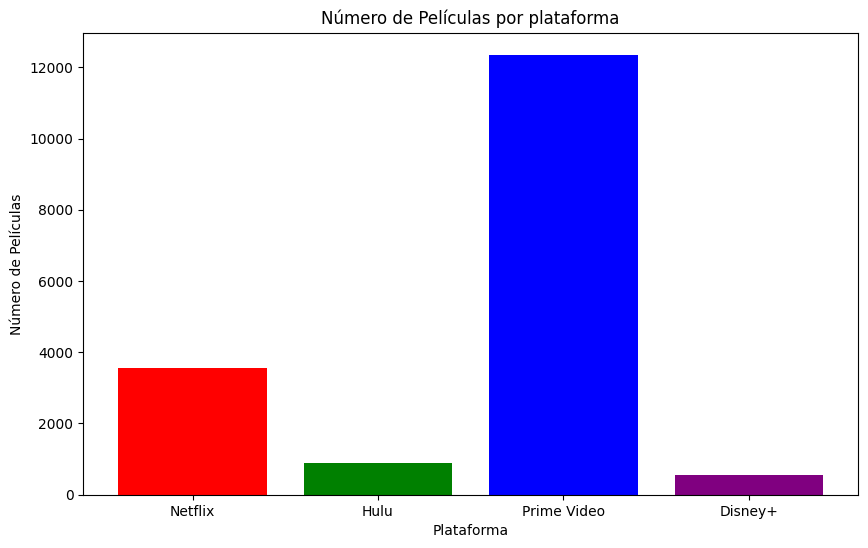

La plataforma con la mayor cantidad de películas disponibles es: Prime Video


In [38]:
peliculas_plataformas = df[['Netflix', 'Hulu', 'Prime Video', 'Disney+']].sum()

plt.figure(figsize=(10, 6))
plt.bar(peliculas_plataformas.index, peliculas_plataformas.values, color=['red', 'green', 'blue', 'purple'])
plt.title('Número de Películas por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Número de Películas')
plt.xticks(rotation=0)
plt.show()


plataforma_max = peliculas_plataformas.idxmax()
print(f'La plataforma con la mayor cantidad de películas disponibles es: {plataforma_max}')


In [39]:
s = df["Directors"].apply(lambda x: str(x).split(",")).dropna()
# print(s)
directores = {x for y in s for x in y }
directores

{"Anthony D'Souza",
 'Sylvie Cozzolino',
 'Sylvia Soska',
 'Marc Vespi',
 'Aleksa Gajic',
 'Olivier Marchal',
 'Doug Gerber',
 'Scott Dobson',
 'Andy Landen',
 'Jonathan Gershfield',
 'Nicholas Nummerdor',
 'Alex Rotaru',
 'Nick Riedell',
 'I. Robert Levy',
 'Alain Desrochers',
 "Tim O'Donnell",
 'Aleksi Antonio Vettenranta',
 'Larry Charles',
 'Giuliano Montaldo',
 'Nicholas Hytner',
 'Jingle Ma',
 'Joseph Kane',
 'Amanda Kramer',
 'Nathan Blair',
 'Lee Cummings',
 'Bruce Wemple',
 'Greg Carter',
 'Tom Gries',
 'Kelsey Thompson',
 'Mike Gan',
 'Ricardo Curtis',
 'Joris Ivens',
 'Kirk R. Thatcher',
 'Ben Meyerson',
 'Hannes Stöhr',
 'Ruben Amar',
 'Scott Rodgers',
 'Robert Allan Ackerman',
 'Jason Paul Laxamana',
 'Chris Rogers',
 'Ryan Polito',
 'Leena Pendharkar',
 'P.J. Hogan',
 'Tom Tykwer',
 'Eric Darnell',
 'Shih Wu',
 'Nick Mead',
 'Jessica Vale',
 'Greg Whiteley',
 'John Chester',
 'Scott W. McKinlay',
 'Liza Mandelup',
 'Ishi Rudell',
 'Christopher Caldwell',
 'Gustave Kervern

In [58]:
t = df[['Netflix']]
lista = []
for x in directores:
    u = pd.concat([t,s, pd.DataFrame([ x in y for y in s])], axis=1)
    # print(u)
    w = u[(u[0] == True) & (u['Netflix'] == 1)]
    lista.append(len(w))
    # print(w)
# z =w.dropna(subset = ['IMDb'])
# print(pd.DataFrame(lista,directores))
# resultado = pd.DataFrame(lista,directores).sort_values(ascending=False)
# print(resultado.head(5))

                       0
Anthony D'Souza        1
Sylvie Cozzolino       0
Sylvia Soska           0
Marc Vespi             0
Aleksa Gajic           0
...                   ..
Brian Helgeland        1
Sange Dorjee Thongdok  0
Bil Yoelin             0
Bradford May           0
William T. Hurtz       0

[12454 rows x 1 columns]


TypeError: sort_values() missing 1 required positional argument: 'by'

In [59]:
print(pd.DataFrame(lista,directores))


                       0
Anthony D'Souza        1
Sylvie Cozzolino       0
Sylvia Soska           0
Marc Vespi             0
Aleksa Gajic           0
...                   ..
Brian Helgeland        1
Sange Dorjee Thongdok  0
Bil Yoelin             0
Bradford May           0
William T. Hurtz       0

[12454 rows x 1 columns]


In [60]:
resultado = pd.DataFrame(lista,directores).sort_values(ascending=False)
print(resultado)

TypeError: sort_values() missing 1 required positional argument: 'by'